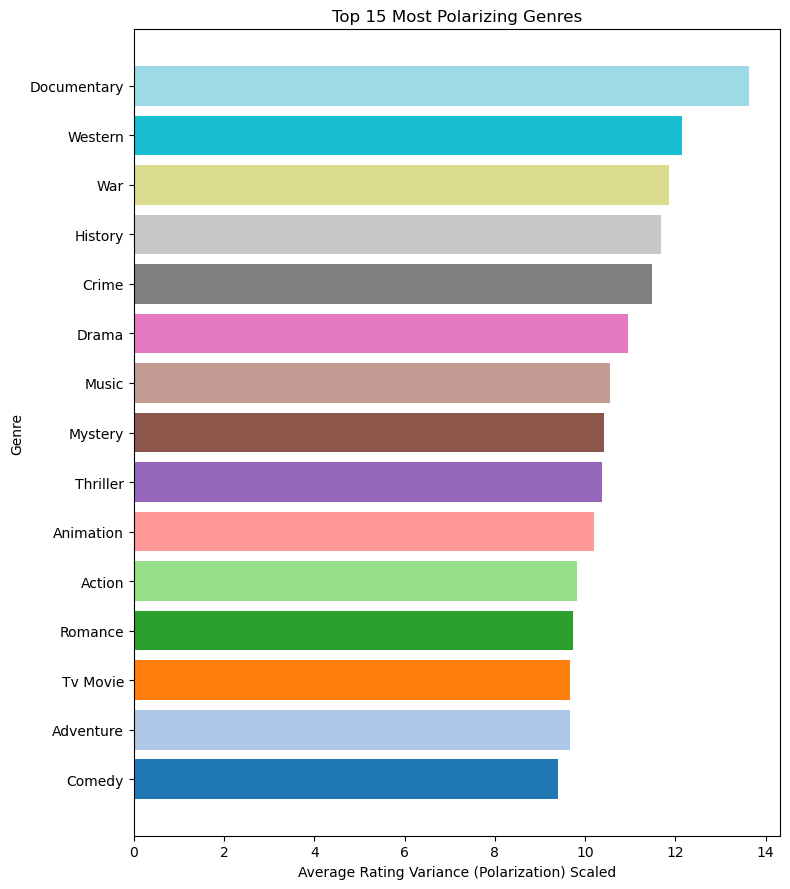

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

# Read data into notebook
df = pd.read_csv("Movie_Data_File.csv")

star_cols = [
    "½",
    "★",
    "★½",
    "★★",
    "★★½",
    "★★★",
    "★★★½",
    "★★★★",
    "★★★★½",
    "★★★★★"
]

# Remove rows without genre
df = df.dropna(subset=["Genres"])

# Genres are comma-separated so split and explode
df["Genres"] = df["Genres"].apply(ast.literal_eval)
df = df.explode("Genres")
# Need to clean genres formatting
df["Genres"] = (
    df["Genres"]
    .str.strip() # Remove leading/trailing spaces
    .str.title() # Standardize capitalization
)

# Calculate total ratings per film
df["Total_Ratings_Calc"] = df[star_cols].sum(axis=1)

# Convert star counts into proportions
for col in star_cols:
    df[col + "_prop"] = df[col] / df["Total_Ratings_Calc"]

prop_cols = [col + "_prop" for col in star_cols]

# Compute variance across rating proportions (polarization metric)
df["rating_variance"] = df[prop_cols].var(axis=1)

# Average polarization per genre
genre_polarization = (
    df.groupby("Genres")["rating_variance"]
    .mean()
    .sort_values(ascending=False)
)

# Show only top 15 most polarized genres for readability
top_n = 15
top_genres = genre_polarization.head(top_n)
top_genres_scaled = top_genres * 1000
sorted_genres = top_genres_scaled.sort_values()
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_genres)))

plt.figure(figsize=(8, 9))
plt.barh(
    sorted_genres.index,
    sorted_genres.values,
    color=colors
)
plt.xlabel("Average Rating Variance (Polarization) Scaled")
plt.ylabel("Genre")
plt.title("Top 15 Most Polarizing Genres")
plt.tight_layout()
plt.show()

In [20]:
# Assistant
def assign_quadrant(row):
    if row["Average_Rating"] >= rating_median and row["Reviews_Millions"] >= review_median:
        return "Acclaimed blockbusters"
    elif row["Average_Rating"] < rating_median and row["Reviews_Millions"] >= review_median:
        return "Commercial triumphs"
    elif row["Average_Rating"] >= rating_median and row["Reviews_Millions"] < review_median:
        return "Cult classics"
    else:
        return "Underperformers"

top_movies["Quadrant"] = top_movies.apply(assign_quadrant, axis=1)

# color map for quadrants
colors = {
    "Acclaimed blockbusters": "green",
    "Commercial triumphs": "orange",
    "Cult classics": "blue",
    "Underperformers": "gray"
}

plt.figure(figsize=(11, 9))

# plot points
for quad in colors:
    subset = top_movies[top_movies["Quadrant"] == quad]
    plt.scatter(
        subset["Average_Rating"],
        subset["Reviews_Millions"],
        label=quad,
        color=colors[quad],
        alpha=0.7
    )

# add quadrant lines
plt.axvline(rating_median, linestyle="--", color="black")
plt.axhline(review_median, linestyle="--", color="black")

# label top 10 most reviewed films in each quadrant
for quad in top_movies["Quadrant"].unique():
    
    quad_subset = top_movies[top_movies["Quadrant"] == quad]
    

# compute distance from quadrant center
top_movies["distance"] = np.sqrt(
    (top_movies["Average_Rating"] - rating_median) ** 2 +
    (top_movies["Reviews_Millions"] - review_median) ** 2
)

# label 5 most extreme films in each quadrant
for quad in top_movies["Quadrant"].unique():
    
    quad_subset = top_movies[top_movies["Quadrant"] == quad]
    
    # pick 5 farthest from the median intersection
    extreme_movies = quad_subset.sort_values(
        "distance",
        ascending=False
    ).head(5)
    
    for _, row in extreme_movies.iterrows():
        plt.annotate(
            row["Film_title"],
            (row["Average_Rating"], row["Reviews_Millions"]),
            fontsize=7
        )

plt.xlabel("Average Rating")
plt.ylabel("Reviews (Millions)")
plt.title("Popularity vs Rating: Quadrant Analysis of Top 150 Films")
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'Average_Rating'

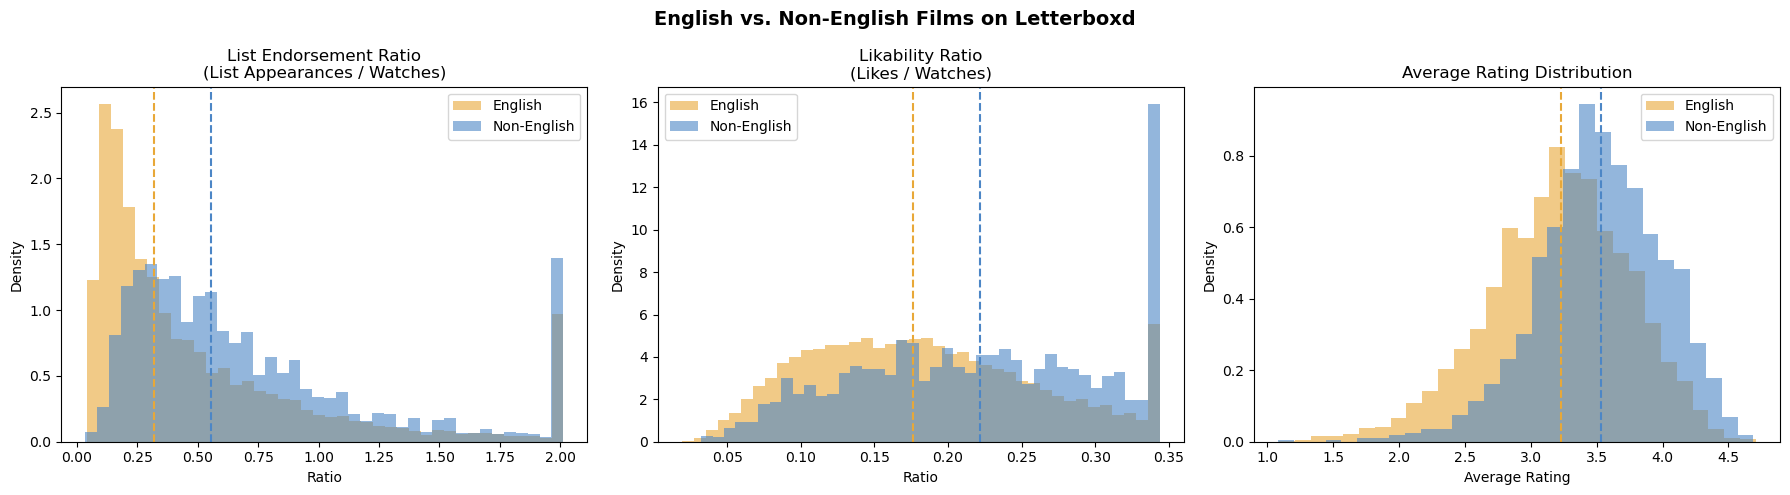

                                    English    Non-English
----------------------------------------------------------
n (films)                             8,072          1,828
Median List/Watch ratio              0.3205         0.5557
Median Likes/Watch ratio             0.1762         0.2215
Median Average Rating                 3.230          3.530


In [4]:
# ── English vs. Non-English Film Analysis ──────────────────────────────────

# Reload original data (before genre explosion from Cell 0)
unique_movies = pd.read_csv("Movie_Data_File.csv").copy()

# Drop rows missing language, remove "No spoken language"
unique_movies = unique_movies.dropna(subset=["Original_language"])
unique_movies = unique_movies[unique_movies["Original_language"] != "No spoken language"]

# Label groups
unique_movies["Language_Group"] = unique_movies["Original_language"].apply(
    lambda x: "English" if x == "English" else "Non-English"
)

# Remove rows with 0 watches or 0 list appearances (avoid divide-by-zero)
unique_movies = unique_movies[
    (unique_movies["Watches"] > 0) &
    (unique_movies["List_appearances"] > 0) &
    (unique_movies["Likes"] > 0)
]

# Compute ratios
unique_movies["list_watch_ratio"] = unique_movies["List_appearances"] / unique_movies["Watches"]
unique_movies["likes_watch_ratio"] = unique_movies["Likes"] / unique_movies["Watches"]

eng     = unique_movies[unique_movies["Language_Group"] == "English"]
non_eng = unique_movies[unique_movies["Language_Group"] == "Non-English"]

# Cap at 95th percentile to reduce skew from outliers
cap_lw   = unique_movies["list_watch_ratio"].quantile(0.95)
cap_like = unique_movies["likes_watch_ratio"].quantile(0.95)

eng_lw_clipped       = eng["list_watch_ratio"].clip(upper=cap_lw)
non_eng_lw_clipped   = non_eng["list_watch_ratio"].clip(upper=cap_lw)
eng_like_clipped     = eng["likes_watch_ratio"].clip(upper=cap_like)
non_eng_like_clipped = non_eng["likes_watch_ratio"].clip(upper=cap_like)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("English vs. Non-English Films on Letterboxd", fontsize=14, fontweight="bold")

BINS = 40
ENG_COLOR = "#E8A838"
NON_COLOR = "#4C86C6"
ALPHA = 0.6

# --- Chart 1: List / Watch ratio ---
axes[0].hist(eng_lw_clipped,     bins=BINS, density=True, alpha=ALPHA, color=ENG_COLOR, label="English")
axes[0].hist(non_eng_lw_clipped, bins=BINS, density=True, alpha=ALPHA, color=NON_COLOR, label="Non-English")
axes[0].axvline(eng["list_watch_ratio"].median(),     color=ENG_COLOR, linestyle="--", linewidth=1.5)
axes[0].axvline(non_eng["list_watch_ratio"].median(), color=NON_COLOR, linestyle="--", linewidth=1.5)
axes[0].set_title("List Endorsement Ratio\n(List Appearances / Watches)")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- Chart 2: Likes / Watch ratio ---
axes[1].hist(eng_like_clipped,     bins=BINS, density=True, alpha=ALPHA, color=ENG_COLOR, label="English")
axes[1].hist(non_eng_like_clipped, bins=BINS, density=True, alpha=ALPHA, color=NON_COLOR, label="Non-English")
axes[1].axvline(eng["likes_watch_ratio"].median(),     color=ENG_COLOR, linestyle="--", linewidth=1.5)
axes[1].axvline(non_eng["likes_watch_ratio"].median(), color=NON_COLOR, linestyle="--", linewidth=1.5)
axes[1].set_title("Likability Ratio\n(Likes / Watches)")
axes[1].set_xlabel("Ratio")
axes[1].set_ylabel("Density")
axes[1].legend()

# --- Chart 3: Average Rating distribution ---
eng_ratings     = eng["Average_rating"].dropna()
non_eng_ratings = non_eng["Average_rating"].dropna()
axes[2].hist(eng_ratings,     bins=30, density=True, alpha=ALPHA, color=ENG_COLOR, label="English")
axes[2].hist(non_eng_ratings, bins=30, density=True, alpha=ALPHA, color=NON_COLOR, label="Non-English")
axes[2].axvline(eng_ratings.median(),     color=ENG_COLOR, linestyle="--", linewidth=1.5)
axes[2].axvline(non_eng_ratings.median(), color=NON_COLOR, linestyle="--", linewidth=1.5)
axes[2].set_title("Average Rating Distribution")
axes[2].set_xlabel("Average Rating")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()

# Print summary stats
print(f"{'':30} {'English':>12} {'Non-English':>14}")
print("-" * 58)
print(f"{'n (films)':30} {len(eng):>12,} {len(non_eng):>14,}")
print(f"{'Median List/Watch ratio':30} {eng['list_watch_ratio'].median():>12.4f} {non_eng['list_watch_ratio'].median():>14.4f}")
print(f"{'Median Likes/Watch ratio':30} {eng['likes_watch_ratio'].median():>12.4f} {non_eng['likes_watch_ratio'].median():>14.4f}")
print(f"{'Median Average Rating':30} {eng_ratings.median():>12.3f} {non_eng_ratings.median():>14.3f}")